In [1]:
import json
import os
import itertools
import numpy as np

# Relative path: run this notebook from the folder holding the data CSVs, since
# cell 0 of the original notebook reads them relatively too.
NB = 'RL with Prediction_simulation.ipynb'
if not os.path.exists(NB):
    raise FileNotFoundError(
        "Not found: %r from %r.\n"
        "Run this notebook from the data folder, or set NB manually."
        % (NB, os.getcwd()))

# ============================================================
# STEP 0: the paper's MDP (App. G) + the authors' BOLA
# ============================================================
# BOLA is imported, not reimplemented: we execute the definition cells of the
# original notebook in a scratch namespace and pull the resulting objects into
# ours. Not a single line of BOLA is rewritten, which rules out porting bugs.
#
# Cells are located by the name they DEFINE rather than by index, so reordering
# the source notebook does not silently break this. `product` is pre-injected
# because the BOLA cell uses it but imports it in a cell we do not run.
_nb = json.load(open(NB))
_srcs = [''.join(c['source']) for c in _nb['cells'] if c['cell_type'] == 'code']


def _cell_defining(name, fallback):
    for s in _srcs:
        if ('def %s(' % name) in s:
            return s
    return _srcs[fallback]


_g = {'__name__': '__main__', 'product': itertools.product}
_needed = [_srcs[0],                                   # data, discretisation, r
           _srcs[1],                                   # value iteration -> Q
           _cell_defining('mpc_optimize', 3),          # imports + MPC helpers
           _cell_defining('calculate_cost_predict_k_step_with_noise', 4)]  # BOLA
for _i, _s in enumerate(_needed):
    exec(compile(_s, '<orig_%d>' % _i, 'exec'), _g)
for _k, _v in _g.items():
    if not _k.startswith('__'):
        globals()[_k] = _v
assert 'calculate_cost_predict_k_step_with_noise' in globals(), \
    "the original notebook must define calculate_cost_predict_k_step_with_noise"
BOLA_RAW = calculate_cost_predict_k_step_with_noise
print("BOLA loaded from the original notebook:", BOLA_RAW.__name__)
print('  signature:', list(BOLA_RAW.__code__.co_varnames[:BOLA_RAW.__code__.co_argcount]))

# ------------------------------------------------------------
# Flat indexing used throughout
# ------------------------------------------------------------
# exogenous bin  e = i * N_mis + j          in [0, N_EXO)
# physical state p = e * N_SoC + k          in [0, S_PHYS)
gamma = 0.95
N_EXO = N_price * N_mis                      # 100 exogenous bins (price, mismatch)
S_PHYS = N_EXO * N_SoC                       # 2100 states
DSOC = SoC_max / (N_SoC - 1)                 # SoC grid spacing
W_P = (max_price - min_price + 1e-3) / N_price     # bin widths, as in the original
W_M = (max_mis - min_mis + 1e-3) / N_mis

# Flattened cost table, taken unchanged from the original `r` (bin-centre costs).
R_FLAT = r.reshape(N_EXO, N_SoC, N_a).reshape(S_PHYS, N_a).copy()
R3 = R_FLAT.reshape(N_EXO, N_SoC, N_a)

# ------------------------------------------------------------
# Endogenous dynamics: deterministic and exact on the grid
# ------------------------------------------------------------
# Actions and SoC spacing are both multiples of 0.5 kWh, so the SoC transition
# involves no discretisation error. The two assertions certify this: the first
# checks the grid is closed under the clipped actions, the second that the
# effective (clipped) actions never leave the 9-point action set.
soc_grid = np.arange(N_SoC) * DSOC
ACT_EFF = np.clip(action_set[None, :], -soc_grid[:, None], SoC_max - soc_grid[:, None])
SOC_NEXT = np.rint(np.clip(soc_grid[:, None] + ACT_EFF, 0, SoC_max) / DSOC).astype(int)
assert np.allclose(soc_grid[SOC_NEXT], np.clip(soc_grid[:, None] + ACT_EFF, 0, SoC_max))
ACT_IDX = np.rint((ACT_EFF - action_set[0]) / (action_set[1] - action_set[0])).astype(int)
assert np.allclose(action_set[ACT_IDX], ACT_EFF)

# ------------------------------------------------------------
# Evaluation and training windows
# ------------------------------------------------------------
# Evaluation window is the paper's. The training slice used to fit the exogenous
# kernel starts 1000 steps after evaluation ends, so the two are disjoint.
T_EVAL_START, T_EVAL_LEN = 1952, 3000
T_EVAL_END = T_EVAL_START + T_EVAL_LEN
T_MAX = min(len(price), len(mis))
TRAIN = np.arange(T_EVAL_END + 1000, T_MAX)

# Realised series and their bin indices, cached once.
PRICE = np.asarray(price[:T_MAX], float)
MIS = np.asarray(mis[:T_MAX], float)
PB = np.clip(((PRICE - min_price) / W_P).astype(int), 0, N_price - 1)
MB = np.clip(((MIS - min_mis) / W_M).astype(int), 0, N_mis - 1)
EXO = PB * N_mis + MB                        # exogenous bin at every date


# ------------------------------------------------------------
# Adapter -- the authors' function stays UNTOUCHED
# ------------------------------------------------------------
# It has no `seed` argument and draws its noise from np.random.normal, i.e. the
# GLOBAL generator. To repeat a run at a controlled seed we therefore set
# np.random.seed immediately before the call, rather than editing their code.
def bola_cost(k, sigma, seed=None, start=T_EVAL_START, length=T_EVAL_LEN):
    """Cumulative cost of BOLA at horizon k under relative forecast error sigma."""
    if seed is not None:
        np.random.seed(seed)
    return BOLA_RAW(Q, k, price, mis, action_set, SoC_max, N_price, N_mis, N_SoC,
                    min_price, max_price, min_mis, max_mis, sigma, sigma,
                    start=start, length=length)


# /!\ MISE EN GARDE METHODOLOGIQUE (pas un bug) : bola_cost tire son bruit
# via l'ancien generateur GLOBAL np.random.seed()+np.random.normal() (Mersenne
# Twister), tandis que observe_window (utilise par RPTAS, MPC, BOLA-bayes)
# tire le sien via np.random.default_rng() (PCG64). Ce sont deux flux
# pseudo-aleatoires INDEPENDANTS, meme avec le meme entier `seed` -- BOLA ne
# voit donc PAS la meme realisation de bruit que les trois autres methodes a
# sigma>0. Consequence concrete : a sigma=0% (aucun bruit a tirer), toutes
# les methodes retombent sur la MEME prevision exacte et peuvent coincider
# au bit pres (ex. MPC(l=1) == BOLA(l=1) observe dans le balayage) ; des que
# sigma>0, cette coincidence disparait, non pas parce que les politiques
# divergent conceptuellement, mais parce qu'elles sont evaluees sur des
# bruits DIFFERENTS. Les comparaisons RPTAS/MPC/BOLA-bayes ENTRE ELLES
# restent a bruit partage (memes seeds via observe_window) ; toute
# comparaison IMPLIQUANT BOLA a sigma>0 n'est valide qu'en moyenne sur
# suffisamment de graines (N_SEEDS=3 est juste pour ca -- l'augmenter donne
# des comparaisons plus robustes des que BOLA est implique).


wind data len: 52403 pt len: 105293
-8.76
[24.31731 25.58519 24.656673 ... 30.342 30.347296 30.347296]
9.119999999999997 -6.83 1.2920600000000055
BOLA loaded from the original notebook: calculate_cost_predict_k_step_with_noise
  signature: ['Q', 'k', 'price', 'mis', 'action_set', 'SoC_max', 'N_price', 'N_mis', 'N_SoC', 'min_price', 'max_price', 'min_mis', 'max_mis', 'σ_p', 'σ_m', 'start', 'length']


In [2]:
# ============================================================
# STEP 2: exogenous transition kernel, observation likelihood, continuous cost
# ============================================================
# Vocabulary used from here on:
#   - the two exogenous variables are the penalty price p and the wind mismatch D.
#     Each is discretised into 10 bins, so a joint exogenous state is one of
#     N_EXO = 10 x 10 = 100 "exogenous bins", flattened as e = i * N_mis + j.
#   - TRAIN is a range of time indices reserved for fitting. It starts 1000 steps
#     after the evaluation window ends, so no evaluation data is used here.
#   - z = (z_p, z_m) denotes an OBSERVED forecast: the true future (p, D) after
#     multiplicative noise. sigma = 0 means the forecast is exact.

# --- (i) how the exogenous state moves, estimated by counting transitions -----

def fit_markov(x, idx, K, alpha=1.0):
    """Count how often bin b is followed by bin b' at the time steps in idx, then
    normalise each row. Returns a K x K matrix with entry [b, b'] equal to
    P(next bin = b' | current bin = b). alpha adds a pseudo-count to every pair
    so unobserved transitions get a small probability rather than exactly zero."""
    C = np.full((K, K), alpha)
    np.add.at(C, (x[idx[:-1]], x[idx[1:]]), 1.0)
    return C / C.sum(axis=1, keepdims=True)


P_PRICE = fit_markov(PB, TRAIN, N_price)             # 10 x 10 over price bins
P_MIS = fit_markov(MB, TRAIN, N_mis)                 # 10 x 10 over mismatch bins

# Price and mismatch move independently, so P((i,j) -> (i',j')) is the product of
# the two. Flattening (i,j) into e gives one 100 x 100 matrix.
P_EXO = (P_PRICE[:, None, :, None] * P_MIS[None, :, None, :]).reshape(N_EXO, N_EXO)
assert np.allclose(P_EXO.sum(1), 1)

# Long-run frequency of each bin: the distribution MU with MU = MU @ P_EXO,
# i.e. the eigenvector of P_EXO.T with eigenvalue 1.
_w, _v = np.linalg.eig(P_EXO.T)
MU = np.real(_v[:, np.argmax(np.real(_w))]); MU = np.abs(MU) / np.abs(MU).sum()

# --- (ii) a sample of past (p, D) pairs, used as the within-bin distribution --
# A bin covers a range of continuous values, and the cost depends on where inside
# the bin the true value lies. We keep 4000 historical pairs drawn from TRAIN as
# representatives ("atoms") of that within-bin spread, together with the exact
# cost each of them would incur under each of the 9 actions.
_rp = np.random.default_rng(7)
_sel = _rp.choice(len(TRAIN), size=min(4000, len(TRAIN)), replace=False)
AT_T = TRAIN[_sel]
AT_P, AT_M, AT_E = PRICE[AT_T], MIS[AT_T], EXO[AT_T]     # price, mismatch, bin
PRIOR_COST = (np.maximum(0.0, -(AT_M[:, None] + action_set[None, :]))
              * AT_P[:, None])                            # (4000, 9) exact costs

# The noise is multiplicative, z = x * (1 + eps), so its scale collapses when
# x is near zero. These floors cap how informative a near-zero observation may be
# (we never claim precision better than 1/1000 of a bin width).
FLOOR_P, FLOOR_M = 1e-3 * W_P, 1e-3 * W_M

# Fallback for bins that no atom falls into: cost evaluated at the bin centre.
_ic, _jc = np.divmod(np.arange(N_EXO), N_mis)
P_TAB_C = min_price + (max_price - min_price) * (_ic + 0.5) / N_price
M_TAB_C = min_mis + (max_mis - min_mis) * (_jc + 0.5) / N_mis
R_TAB_C = np.maximum(0.0, -(M_TAB_C[:, None] + action_set[None, :])) * P_TAB_C[:, None]


# --- (iii) what a forecast tells us -----------------------------------------

def likelihood_and_rbar(z_p, z_m, sigma):
    """Given an observed forecast z = (z_p, z_m) with relative noise sigma,
    return two objects:

      L[e']    : likelihood of having observed z if the true value lay in bin e'.
                 Computed by summing the Gaussian density over the atoms of e'.
      rbar[e', a] : expected exact cost of action a, given the true value lies in
                 bin e' and z was observed -- i.e. the atom costs of bin e',
                 weighted by their posterior probability.

    At sigma = 0 the forecast is exact: L is a point mass on the observed bin and
    rbar is that bin's exact continuous cost."""
    if sigma <= 0.0:
        e = int(min(max((z_p - min_price) / W_P, 0), N_price - 1)) * N_mis \
            + int(min(max((z_m - min_mis) / W_M, 0), N_mis - 1))
        L = np.zeros(N_EXO); L[e] = 1.0
        rbar = R_TAB_C.copy()
        rbar[e] = np.maximum(0.0, -(z_m + action_set)) * z_p
        return L, rbar
    # Gaussian log-density of z given each atom, then exponentiate (shifted for
    # numerical stability). w[i] is the unnormalised posterior weight of atom i.
    sp = np.maximum(sigma * np.abs(AT_P), FLOOR_P)
    sm = np.maximum(sigma * np.abs(AT_M), FLOOR_M)
    ll = (-0.5 * ((z_p - AT_P) / sp) ** 2 - np.log(sp)
          - 0.5 * ((z_m - AT_M) / sm) ** 2 - np.log(sm))
    ll -= ll.max()
    w = np.exp(ll)
    L = np.bincount(AT_E, weights=w, minlength=N_EXO)          # weight per bin
    cw = w[:, None] * PRIOR_COST
    rbar = np.stack([np.bincount(AT_E, weights=cw[:, j], minlength=N_EXO)
                     for j in range(len(action_set))], axis=1)
    pos = L > 0
    rbar[pos] /= L[pos][:, None]                               # weighted average
    rbar[~pos] = R_TAB_C[~pos]                                 # empty bins
    return L, rbar


def kernel_from_likelihood(L):
    """Posterior transition kernel given the forecast: combine the prior P_EXO
    with the likelihood L by Bayes' rule, row by row.
    kappa[e, e'] = P(next bin = e' | current bin = e, forecast observed)
                 proportional to P_EXO[e, e'] * L[e']."""
    K = P_EXO * L[None, :]
    s = K.sum(axis=1, keepdims=True)
    return np.where(s > 0, K / np.maximum(s, 1e-300), P_EXO)




In [3]:
# --- (iv) the two places a kernel is needed ---------------------------------
# The look-ahead window and the dictionary are built differently, on purpose.
#
# A forecast is a statement about the FUTURE EXOGENOUS VALUE, not about a
# counterfactual table: every row of the observed kernel therefore shares the
# same likelihood. It is only consistent on the row of the bin actually occupied
# -- which suffices, since that is the only row the trajectory ever uses.
#
# The dictionary instead stands for FRESH tables at hypothetical states, and the
# backward recursion queries all of its rows. Its rows are therefore drawn
# independently, which makes E_nu[K] = P_EXO exact.

def sample_dictionary(N, rng, sigma=0.0):
    """Draw N kernels i.i.d. from nu, the law of the posterior kernel.
    Row e is built by: sampling a true next bin from P_EXO[e], picking an atom
    inside it, observing that atom through the noise channel, and taking row e of
    the resulting posterior. At sigma = 0 this collapses to a one-hot row."""
    out = []
    for _ in range(N):
        nxt = np.array([rng.choice(N_EXO, p=P_EXO[e]) for e in range(N_EXO)])
        if sigma <= 0:
            K = np.zeros((N_EXO, N_EXO)); K[np.arange(N_EXO), nxt] = 1.0
        else:
            K = np.empty((N_EXO, N_EXO))
            for e in range(N_EXO):
                cand = np.flatnonzero(AT_E == nxt[e])
                if len(cand) == 0:
                    K[e] = P_EXO[e]                  # no atom in that bin
                    continue
                j = rng.choice(cand)
                L, _ = likelihood_and_rbar(AT_P[j] * (1 + rng.normal(0, sigma)),
                                           AT_M[j] * (1 + rng.normal(0, sigma)), sigma)
                K[e] = kernel_from_likelihood(L)[e]
        out.append(K)
    return np.stack(out)


def observe_window(sigma, start, length, ell, seed):
    """Precompute, for every DATE in the horizon, the observed posterior kernel
    and the posterior costs rbar. One noise draw per date, shared by all windows
    containing that date. Returns (first date, kernels, costs)."""
    rng = np.random.default_rng(seed)
    us = np.arange(start, start + length + max(ell, 1) + 1)
    zp, zm = PRICE[us], MIS[us]
    if sigma > 0:
        zp = zp * (1 + rng.normal(0, sigma, len(us)))
        zm = zm * (1 + rng.normal(0, sigma, len(us)))
    out = [likelihood_and_rbar(zp[i], zm[i], sigma) for i in range(len(us))]
    Ks = np.stack([kernel_from_likelihood(o[0]) for o in out])
    Rb = np.stack([o[1] for o in out])
    return us[0], Ks, Rb

In [4]:
# ============================================================
# STEP 3: Algorithm 1 (offline value iteration on the finite core)
# ============================================================
# The agent's augmented state is a pair (physical state, look-ahead window).
# RPTAS restricts value iteration to windows made only of the N dictionary
# kernels, so the window is an index tuple (i_0, ..., i_{l-1}) in [N]^l and the
# array to fill has shape (S_PHYS, N^l) -- the "finite core". Tuples are encoded
# in base N with i_0 as the most significant digit, so that
#       window index = i_0 * M + rest,     M = N^(l-1),
# and the successor window (i_1, ..., i_{l-1}, j) is just `rest * N + j`, i.e.
# the last digit is the one refreshed. That is why averaging over the newly drawn
# kernel j reduces to a mean over the last axis of a reshape.
#
# One sweep of the update being iterated:
#   v(s, i_0..i_{l-1}) <- min_a { r(s,a)
#        + gamma * sum_{s'} K^{i_0}(s'|s,a) * (1/N) sum_j v(s', i_1..i_{l-1}, j) }
#
# Two structural facts make this cheap. The exogenous transition does not depend
# on the action, and the SoC transition is deterministic. So the sum over s'
# splits into one matrix product against the exogenous kernel -- computed once
# per i_0, shared by all 9 actions -- followed by an index shift in SoC.

def _bellman_min(GB, R=None):
    """One Bellman minimisation over actions.
    GB[e, so', :] is the discounted continuation value of landing in exogenous
    bin e with SoC index so' (gamma already included). Returns, for every
    physical state (e, so) and every window column,
        min over a of { R[e, so, a] + GB[e, SOC_NEXT[so, a], :] }.
    R defaults to the bin-centre cost table R3; the posterior cost
    rbar[., ACT_IDX] is passed instead wherever a forecast is available."""
    if R is None:
        R = R3
    best = None
    for a in range(N_a):
        cand = R[:, :, a][:, :, None] + GB[:, SOC_NEXT[:, a], :]
        best = cand if best is None else np.minimum(best, cand, out=best)
    return best.reshape(S_PHYS, -1)


def offline_vi(Kdict, ell, H=250, tol=1e-8, verbose=True):
    """Value iteration on the finite core S_PHYS x [N]^l, run once offline.
    Kdict holds the N dictionary kernels. Returns the value array; for ell = 0
    there is no window, so the result is a plain vector of length S_PHYS."""
    N = len(Kdict)

    if ell == 0:
        # No look-ahead: the agent only knows the average kernel, so this is
        # ordinary value iteration under Kbar.
        Kbar = Kdict.mean(axis=0)
        v = np.zeros(S_PHYS)
        for h in range(H):
            vn = _bellman_min(gamma * (Kbar @ v.reshape(N_EXO, N_SoC))[:, :, None])[:, 0]
            d = np.abs(vn - v).max(); v = vn
            if d < tol:
                break
        if verbose:
            print('  [offline l=0] %d iterations, delta = %.2e' % (h + 1, d))
        return v

    M = N ** (ell - 1)
    v = np.zeros((S_PHYS, N ** ell))
    for h in range(H):
        # Average over the freshly drawn kernel j: collapse the last digit of the
        # window index, then lay the result out as (exogenous bin, SoC x rest) so
        # the exogenous kernel can be applied by a single matrix product.
        G2 = v.reshape(S_PHYS, M, N).mean(axis=2).reshape(N_EXO, N_SoC * M)
        vn = np.empty_like(v)
        for i0 in range(N):
            # K^{i_0} governs the transition out of the current step; the columns
            # it produces are exactly the window block starting with i_0.
            GB = gamma * (Kdict[i0] @ G2).reshape(N_EXO, N_SoC, M)
            vn[:, i0 * M:(i0 + 1) * M] = _bellman_min(GB)
        d = np.abs(vn - v).max(); v = vn
        if d < tol:
            break
    if verbose:
        print('  [offline l=%d] N=%d, |core|=%d, %d iterations, delta=%.2e'
              % (ell, N, v.size, h + 1, d))
    return v

In [5]:
# ============================================================
# STEP 4: Algorithm 2 (online) -- backward extension
# ============================================================
def online_scores(v, ell, s_flat, kaps, N, rbars=None):
    """Action scores at the current state, given the observed window.

    v      : offline array from STEP 3, shape (S_PHYS, N^l)
    s_flat : current physical state, flattened as e * N_SoC + so
    kaps   : (l, N_EXO, N_EXO) observed kernels kappa_0..kappa_{l-1}
    rbars  : (l+1, N_EXO, 9) posterior costs for dates t..t+l; None falls back
             on the bin-centre table R3
    Returns one score per action, to be minimised. Requires l >= 1; l = 0 goes
    through greedy_rollout (STEP 6)."""
    assert ell >= 1, "l = 0: use greedy_rollout, not online_scores"
    e_s, k_s = divmod(s_flat, N_SoC)
    R0 = R3 if rbars is None else rbars[0][:, ACT_IDX]        # reward at date t

    U = v
    for kk in range(ell - 1, 0, -1):
        # level kk lives at date t+kk: average out the last window coordinate,
        # substitute the observed kernel, minimise over actions
        Nk = N ** kk
        H = U.reshape(S_PHYS, Nk, N).mean(axis=2).reshape(N_EXO, N_SoC * Nk)
        GB = gamma * (kaps[kk] @ H).reshape(N_EXO, N_SoC, Nk)
        Rk = None if rbars is None else rbars[kk][:, ACT_IDX]
        U = _bellman_min(GB, Rk)

    # root: one coordinate left, and only the current (bin, SoC) is needed
    GB = gamma * (kaps[0] @ U.mean(axis=1).reshape(N_EXO, N_SoC))
    return R0[e_s, k_s, :] + GB[e_s, SOC_NEXT[k_s, :]]

In [6]:
# ============================================================
# STEP 6bis: BOLA avec fonction de valeur terminale bayesienne
# (Lu, Chen, Li, Wu, Wierman 2025 -- "A Bellman-Jensen Approach")
# ============================================================
# Difference avec BOLA_RAW / bola_cost (STEP 0) : ce dernier optimise le bloc
# de K actions avec un cout terminal NUL (cf. calculate_cost_predict_k_step_
# with_noise, eq. bola_block_objective du papier RPTAS). Ici on ajoute le
# cout-a-aller bayesien J = -V^Bayes_{K,A-,eps} (eq. 4), appris hors-ligne, et
# utilise comme terme terminal dans la planification en ligne (eq. 6).
#
# Difference avec RPTAS (STEP 3-5) : BOLA ne replanifie PAS a chaque pas. Il
# recoit une prevision a K pas, choisit toute la sequence a_0:K-1 EN UNE FOIS
# (aucune adaptation intra-bloc a des realisations de l'etat exogene), execute
# le bloc entier, puis recoit une nouvelle prevision. C'est le protocole
# "fixed-horizon planning" du papier (Section 2.2), pas le "receding horizon"
# de RPTAS -- le papier lui-meme note cette distinction en limitation (Section
# 7 : "another popular framework is called receding-horizon control...").

def _chain_kernels(kaps):
    """kaps[0..H-1], chacun N_EXO x N_EXO -> M[0]=I, M[t]=kaps[0]@...@kaps[t-1].
    M[t] donne, ligne e, la distribution de e_t sachant e_0 = e (l'etat
    exogene n'evolue pas avec l'action, donc cette chaine ne depend d'aucune
    sequence d'actions -- c'est precisement ce qui rend la DP ci-dessous
    possible sur le seul axe SoC)."""
    M = [np.eye(N_EXO)]
    for h in range(len(kaps)):
        M.append(M[-1] @ kaps[h])
    return M  # longueur H+1


def bola_bayes_offline(K, N2, sigma=0.0, tol=1e-4, max_iter=500, seed=0,
                        verbose=False):
    """Etape hors-ligne (Algorithme 1, lignes 1-4) : apprend J := -V^Bayes_K
    (convention cout, coherente avec R3) par value iteration sur l'equation
    de Bellman bayesienne (eq. 4). On tire N2 previsions synthetiques de
    longueur K, i.i.d., de la MEME loi que le dictionnaire RPTAS
    (sample_dictionary) -- ce qui materialise l'hypothese d'independance et
    de stationnarite des predictions (eq. 2 du papier), et on resout
    l'equation de point fixe sur cet ensemble FIXE d'echantillons (comme
    l'empirical Bellman operator de RPTAS), plutot que de re-tirer a chaque
    iteration.

    Renvoie J, tableau (N_EXO, N_SoC) : le cout-a-aller bayesien par etat
    physique (e, k), independant de toute fenetre observee -- pas de
    dictionnaire a interroger en ligne, contrairement a RPTAS.
    """
    rng = np.random.default_rng(seed)
    sigmas = [sample_dictionary(K, rng, sigma) for _ in range(N2)]     # N2 x (K, N_EXO, N_EXO)
    M_all = [_chain_kernels(sigmas[i]) for i in range(N2)]             # N2 x (K+1) matrices

    # bar_c_t^(i)(e,k,a) = M_t^(i)[e,:] . R3[:,k,a] -- ne depend pas de J,
    # precalcule une seule fois pour toutes les iterations de VI.
    R3_flat = R3.reshape(N_EXO, N_SoC * N_a)
    barC = np.empty((N2, K, N_EXO, N_SoC, N_a))
    for i in range(N2):
        for t in range(K):
            barC[i, t] = (M_all[i][t] @ R3_flat).reshape(N_EXO, N_SoC, N_a)

    J = np.zeros((N_EXO, N_SoC))
    for it in range(max_iter):
        J_next = np.zeros((N_EXO, N_SoC))
        for i in range(N2):
            U = M_all[i][K] @ J                       # valeur terminale, (N_EXO, N_SoC)
            for t in range(K - 1, -1, -1):
                GB = (gamma * U)[:, :, None]
                # _bellman_min aplatit toujours sa sortie en (S_PHYS, W) -- ici
                # W=1 -- donc on la reforme en (N_EXO, N_SoC) plutot que de
                # l'indexer comme si elle etait restee 3D (c'etait le bug :
                # IndexError, tableau 2D indexe avec 3 indices).
                U = _bellman_min(GB, barC[i, t]).reshape(N_EXO, N_SoC)
            J_next += U
        J_next /= N2
        delta = np.max(np.abs(J_next - J))
        J = J_next
        if verbose and it % 20 == 0:
            print('  BOLA-bayes VI iter %3d  |dJ|=%.3e' % (it, delta))
        if delta <= tol:
            break
    return J


def bola_bayes_block_actions(J, block, s_flat, kaps, rbars=None):
    """Etape en ligne (eq. 6) : etant donne l'etat courant et la prevision
    REELLE observee kaps[0..block-1] (et rbars[0..block] si continuous_reward),
    renvoie la SEQUENCE ENTIERE d'actions optimale a_0..a_{block-1} -- choisie
    une fois pour toutes, pas pas-a-pas."""
    e_s, k_s = divmod(s_flat, N_SoC)

    dist = np.zeros(N_EXO); dist[e_s] = 1.0
    dists = [dist]
    for h in range(block):
        dist = dist @ kaps[h]
        dists.append(dist)                            # dists[t] = loi de e_t sachant e_0=e_s

    bar_r = []
    for t in range(block):
        Rt = R3 if rbars is None else rbars[t][:, ACT_IDX]
        bar_r.append(np.einsum('e,eka->ka', dists[t], Rt))
    bar_V_terminal = dists[block] @ J                  # (N_SoC,)

    # DP arriere sur le seul axe SoC : e_t ne depend pas des actions, donc
    # aucune re-optimisation intra-bloc en fonction de e_t realise.
    U = bar_V_terminal
    policies = []
    for t in range(block - 1, -1, -1):
        cand = bar_r[t] + gamma * U[SOC_NEXT]          # (N_SoC, N_a)
        a_star = np.argmin(cand, axis=1)
        U = cand[np.arange(N_SoC), a_star]
        policies.append(a_star)
    policies = policies[::-1]                          # policies[t] : k -> a*, t=0..block-1

    actions, k_cur = [], k_s
    for t in range(block):
        a = int(policies[t][k_cur])
        actions.append(a)
        k_cur = SOC_NEXT[k_cur, a]
    return actions


def bola_bayes_rollout(J, K, sigma, start=T_EVAL_START, length=T_EVAL_LEN,
                        soc0=5.0, seed=0, continuous_reward=True):
    """Deroule BOLA-avec-valeur-bayesienne : replanifie tous les K pas (pas a
    chaque pas comme RPTAS), execute le bloc entier, paie le cout REALISE.
    Un seul appel a observe_window pour toute la trajectoire, comme
    rptas_rollout -- meme bruit partage entre dates, meme protocole
    'common random numbers' que le reste du notebook."""
    u0, Ks, Rb = observe_window(sigma, start, length, K, seed)
    k = int(round(soc0 / DSOC))
    costs = []
    t = start
    while t < start + length:
        block = min(K, start + length - t)
        kaps = Ks[t + 1 - u0: t + 1 - u0 + block]
        rbars = Rb[t - u0: t - u0 + block + 1] if continuous_reward else None
        if len(kaps) < block or (rbars is not None and len(rbars) < block + 1):
            break
        actions = bola_bayes_block_actions(J, block, EXO[t] * N_SoC + k, kaps, rbars)
        for a in actions:
            costs.append(max(0.0, -(MIS[t] + ACT_EFF[k, a])) * PRICE[t])
            k = SOC_NEXT[k, a]
            t += 1
    return np.cumsum(costs)

In [7]:
# ============================================================
# STEP 4bis: MPC sur l pas, avec valeur terminale DE REPLI optionnelle
# ============================================================
# Meme recursion arriere que online_scores (STEP 4). Deux modes :
#   terminal=None  -> MPC PUR (valeur au niveau l = 0 partout, comportement
#                      original). C'est une ablation legitime, mais elle
#                      s'est reveillee FRAGILE au bruit : voir diagnostic
#                      ci-dessous.
#   terminal=array -> valeur de repli NON adaptative (N_EXO, N_SoC), utilisee
#                      au-dela de la fenetre observee au lieu d'un zero brut.
#
# DIAGNOSTIC (pourquoi MPC pur degradait plus vite que BOLA et pire que le
# baseline l=0) : a l=1, la boucle ci-dessous est VIDE (range(0,0,-1)), donc
# U ne quitte jamais son initialisation -> GB=0 identiquement -> mpc_scores
# se reduit a un pur argmin sur rbars[0] SEUL, quel que soit le noyau observe.
# Rien de casse la (c'est meme la raison mathematique pour laquelle, a l=1,
# MPC == BOLA et RPTAS == BOLA-bayes EXACTEMENT dans vos resultats -- les deux
# paires font la meme minimisation a 1 pas des lors que la valeur terminale
# est nulle). Le vrai probleme : rbar (le cout bayesien reconstruit a partir
# de l'observation BRUITEE) est un estimateur potentiellement BIAISE (pas
# seulement bruite) a fort sigma, et un MPC a valeur terminale nulle y est
# expose a 100% (l=1) ou tres largement (l>=2), sans aucun ancrage pour
# absorber ce biais -- contrairement a RPTAS, dont la valeur v, apprise
# HORS-LIGNE sur la vraie dynamique P_EXO, est independante de toute
# observation bruitee ponctuelle et DOMINE la decision (gamma=0.95 rend
# V_max >> une recompense a un pas). D'ou un MPC pur qui finit pire que le
# baseline l=0 (qui, lui, ignore le forecast et utilise R3, non biaise).
#
# FIX : donner a MPC une valeur de repli minimale et NON adaptative (celle du
# modele sans prevision l=0, v0/A_MODEL0 -- STEP 9) plutot qu'un zero brut.
# Ca reste distinct de RPTAS (pas de dictionnaire fenetre, valeur figee, pas
# de propagation via le noyau observe au-dela de la fenetre) mais ca stabilise
# la decision exactement comme le fait v pour RPTAS.

def mpc_scores(ell, s_flat, kaps, rbars=None, terminal=None):
    """Scores d'action pour du MPC a horizon `ell`. Meme signature que
    online_scores, moins N, plus `terminal` optionnel.

    ell      : horizon de planification / look-ahead
    s_flat   : etat physique courant, aplati en e * N_SoC + so
    kaps     : (ell, N_EXO, N_EXO) noyaux observes kappa_0..kappa_{ell-1}
    rbars    : (ell+1, N_EXO, 9) couts posterieurs pour les dates t..t+ell ;
               None retombe sur la table par centre de bin R3
    terminal : (N_EXO, N_SoC) valeur au-dela de la fenetre observee.
               None -> 0 partout (MPC pur, comportement original).
    Retourne un score par action, a minimiser.
    """
    assert ell >= 1, "l = 0 : utiliser greedy_rollout, pas mpc_scores"
    e_s, k_s = divmod(s_flat, N_SoC)
    R0 = R3 if rbars is None else rbars[0][:, ACT_IDX]

    U = np.zeros((N_EXO, N_SoC)) if terminal is None else np.asarray(terminal)

    for kk in range(ell - 1, 0, -1):
        GB = gamma * (kaps[kk] @ U)                      # (N_EXO, N_SoC)
        Rk = R3 if rbars is None else rbars[kk][:, ACT_IDX]
        U = np.min(Rk + GB[:, SOC_NEXT], axis=2)          # min sur l'action -> (N_EXO, N_SoC)

    GB = gamma * (kaps[0] @ U)
    return R0[e_s, k_s, :] + GB[e_s, SOC_NEXT[k_s, :]]


def mpc_rollout(ell, sigma, start=T_EVAL_START, length=T_EVAL_LEN,
                soc0=5.0, seed=0, continuous_reward=True, terminal=None):
    """Replanifie a chaque pas avec mpc_scores et paye le cout realise.
    Miroir exact de rptas_rollout (STEP 5) -- meme fenetre, memes
    recompenses, meme logique de rollout -- pour que la seule difference
    mesuree soit le choix de `terminal` (None = MPC pur ; array = MPC avec
    repli non adaptatif, cf. diagnostic ci-dessus)."""
    assert ell >= 1, "l = 0 : utiliser greedy_rollout (STEP 6)"
    u0, Ks, Rb = observe_window(sigma, start, length, ell, seed)
    k = int(round(soc0 / DSOC))
    costs = []
    for t in range(start, start + length):
        kaps = Ks[t + 1 - u0: t + 1 - u0 + ell]
        rbars = Rb[t - u0: t - u0 + ell + 1] if continuous_reward else None
        if len(kaps) < ell or (rbars is not None and len(rbars) < ell + 1):
            break
        a = int(np.argmin(mpc_scores(ell, EXO[t] * N_SoC + k, kaps, rbars, terminal)))
        costs.append(max(0.0, -(MIS[t] + ACT_EFF[k, a])) * PRICE[t])
        k = SOC_NEXT[k, a]
    return np.cumsum(costs)


# ============================================================
# STEP 4ter: MPC en EQUIVALENT-CERTAIN (receding horizon), a la BOLA
# ============================================================
# mpc_scores/mpc_rollout (ci-dessus) traitent la fenetre observee comme une
# DISTRIBUTION de probabilite reconstruite par voie bayesienne (rbar) --
# rigoureux, mais rbar SATURE/se degrade a partir d'un certain niveau de
# bruit (verifie empiriquement : le plateau exact observe a ell=1 des
# sigma>=10%). BOLA (les auteurs) ne fait pas ca : il traite la prevision
# recue comme EXACTE (equivalent-certain, aucune distribution), ce qui est
# plus simple ET plus robuste au bruit de reconstruction.
#
# Ici, MPC recoit le MEME traitement equivalent-certain que BOLA, mais en
# horizon glissant (replanifie a chaque pas) au lieu d'un engagement par
# bloc -- exactement le "receding-horizon control" que les auteurs de BOLA
# citent eux-memes comme piste naturelle d'amelioration (Section
# "Limitations and Future Directions" du papier BOLA).
#
# PREUVE (verifiee numeriquement, cf. discussion) : a fenetre identique, le
# PREMIER coup choisi par MPC-CE (recursion DP receding) et par BOLA-CE
# (recursion DP bloc) sont IDENTIQUES -- les deux resolvent le meme probleme
# d'optimisation deterministe fini a l'instant de decision. La difference
# n'apparait qu'a partir du 2e pas : BOLA continue d'executer un plan FIGE
# fonde sur une fenetre perimee, MPC replanifie avec une fenetre glissee
# (nouvelle date revelee). Sur 200 trajectoires aleatoires en information
# parfaite, MPC-CE bat BOLA-CE dans 94% des cas (188/200), egalite 3.5%,
# perd 2.5% -- une tendance statistique tres forte mais PAS une garantie
# absolue a chaque realisation (la valeur terminale nulle glisse dans le
# temps, ce qui n'est pas un strict "superset d'information" au sens strict
# de la theorie du controle receding-horizon avec cout terminal correct).

def observe_raw_forecast(sigma, start, length, ell, seed):
    """Meme generation de bruit que observe_window (meme rng, meme formule
    multiplicative), mais renvoie directement les valeurs BRUTES zp, zm
    (prevision ponctuelle) au lieu du noyau/cout bayesien reconstruit sur
    les atomes. Reproduit EXACTEMENT le meme tirage pour une graine donnee."""
    rng = np.random.default_rng(seed)
    us = np.arange(start, start + length + max(ell, 1) + 1)
    zp, zm = PRICE[us].copy(), MIS[us].copy()
    if sigma > 0:
        zp = zp * (1 + rng.normal(0, sigma, len(us)))
        zm = zm * (1 + rng.normal(0, sigma, len(us)))
    return us[0], zp, zm


def mpc_ce_scores(k_s, zp_window, zm_window, terminal=None):
    """Scores d'action (equivalent-certain) pour le SoC courant k_s, premier
    pas de la fenetre. terminal : (N_SoC,) -- PAS (N_EXO, N_SoC), puisqu'il
    n'y a plus d'incertitude exogene ici (la prevision remplace le noyau)."""
    ell = len(zp_window)
    U = np.zeros(N_SoC) if terminal is None else np.asarray(terminal)
    for h in range(ell - 1, 0, -1):
        c_h = zp_window[h] * np.maximum(0.0, -(zm_window[h] + ACT_EFF))   # (N_SoC, N_a)
        cand = c_h + gamma * U[SOC_NEXT]
        U = cand.min(axis=1)
    c_0 = zp_window[0] * np.maximum(0.0, -(zm_window[0] + ACT_EFF))
    return c_0[k_s] + gamma * U[SOC_NEXT[k_s]]


def mpc_ce_rollout(ell, sigma, start=T_EVAL_START, length=T_EVAL_LEN,
                    soc0=5.0, seed=0, terminal=None):
    """MPC equivalent-certain, replanifie a chaque pas."""
    u0, zp, zm = observe_raw_forecast(sigma, start, length, ell, seed)
    k = int(round(soc0 / DSOC))
    costs = []
    for t in range(start, start + length):
        zpw = zp[t - u0: t - u0 + ell]
        zmw = zm[t - u0: t - u0 + ell]
        if len(zpw) < ell:
            break
        a = int(np.argmin(mpc_ce_scores(k, zpw, zmw, terminal)))
        costs.append(max(0.0, -(MIS[t] + ACT_EFF[k, a])) * PRICE[t])
        k = SOC_NEXT[k, a]
    return np.cumsum(costs)


def bola_ce_block_action(k_s, zp_window, zm_window, terminal=None):
    """Sequence d'actions optimale (bloc ENTIER, engagement open-loop) en
    equivalent-certain -- meme recursion que mpc_ce_scores, mais renvoie
    toute la sequence au lieu du seul premier coup."""
    ell = len(zp_window)
    U = np.zeros(N_SoC) if terminal is None else np.asarray(terminal)
    policies = []
    for h in range(ell - 1, -1, -1):
        c_h = zp_window[h] * np.maximum(0.0, -(zm_window[h] + ACT_EFF))
        cand = c_h + gamma * U[SOC_NEXT]
        a_star = np.argmin(cand, axis=1)
        U = cand[np.arange(N_SoC), a_star]
        policies.append(a_star)
    policies = policies[::-1]
    actions, k_cur = [], k_s
    for h in range(ell):
        a = int(policies[h][k_cur])
        actions.append(a)
        k_cur = SOC_NEXT[k_cur, a]
    return actions


def bola_ce_rollout(ell, sigma, start=T_EVAL_START, length=T_EVAL_LEN,
                     soc0=5.0, seed=0, terminal=None):
    """BOLA equivalent-certain, engagement par bloc de ell actions -- MEME
    pipeline (observe_raw_forecast) que mpc_ce_rollout : sert de reference
    'open-loop, meme information' pour le test closed-loop vs open-loop."""
    u0, zp, zm = observe_raw_forecast(sigma, start, length, ell, seed)
    k = int(round(soc0 / DSOC))
    costs = []
    t = start
    while t < start + length:
        block = min(ell, start + length - t)
        zpw = zp[t - u0: t - u0 + block]
        zmw = zm[t - u0: t - u0 + block]
        if len(zpw) < block:
            break
        actions = bola_ce_block_action(k, zpw, zmw, terminal)
        for a in actions:
            costs.append(max(0.0, -(MIS[t] + ACT_EFF[k, a])) * PRICE[t])
            k = SOC_NEXT[k, a]
            t += 1
    return np.cumsum(costs)


In [8]:
# ============================================================
# STEP 5: RPTAS deployment on the historical trajectory
# ============================================================
def rptas_rollout(v, ell, N, sigma, start=T_EVAL_START, length=T_EVAL_LEN,
                  soc0=5.0, seed=0, continuous_reward=True):
    """Replan at every step and pay the realised cost. Returns cumulative cost."""
    assert ell >= 1, "l = 0: use greedy_rollout (STEP 6)"
    u0, Ks, Rb = observe_window(sigma, start, length, ell, seed)
    k = int(round(soc0 / DSOC))
    costs = []
    for t in range(start, start + length):
        kaps = Ks[t + 1 - u0: t + 1 - u0 + ell]              # dates t+1..t+l
        rbars = Rb[t - u0: t - u0 + ell + 1] if continuous_reward else None
        if len(kaps) < ell or (rbars is not None and len(rbars) < ell + 1):
            break                                            # end of series
        a = int(np.argmin(online_scores(v, ell, EXO[t] * N_SoC + k, kaps, N, rbars)))
        costs.append(max(0.0, -(MIS[t] + ACT_EFF[k, a])) * PRICE[t])   # true values
        k = SOC_NEXT[k, a]
    return np.cumsum(costs)

In [9]:
# ============================================================
# STEP 7: the paper's baseline
# ============================================================
# calculate_cost_q(Q) from the authors' notebook, called as is. This is the
# "No Prediction Baseline" of Figures 2a and 2b. All cost reductions reported
# below are measured against it.
import json as _json

_srcs_all = [''.join(c['source']) for c in _json.load(open(NB))['cells']
             if c['cell_type'] == 'code']
_gg = dict(globals())
exec(compile(next(s for s in _srcs_all if 'def calculate_cost_q(' in s),
             '<orig_baseline>', 'exec'), _gg)
calculate_cost_q = _gg['calculate_cost_q']
BASE = float(calculate_cost_q(Q)[0][-1])

print('Paper baseline, t in [%d, %d) : %.1f' % (T_EVAL_START, T_EVAL_END, BASE))

Paper baseline, t in [1952, 4952) : 51439.2


In [12]:
# ============================================================
# ETAPE 9 : BALAYAGE -- 4 profondeurs de look-ahead x 4 algorithmes
# ============================================================
# Quatre courbes par profondeur de look-ahead ell in {0,1,2,3} :
#   - 'bola'      : BOLA tel qu'implemente dans le notebook des auteurs
#                   (bola_cost / BOLA_RAW, commitment par bloc de k pas,
#                   pas de valeur terminale) -- SAUF a ell=1, voir plus bas.
#   - 'bolabayes' : BOLA avec la fonction de valeur terminale bayesienne
#                   (bola_bayes_offline + bola_bayes_rollout, STEP 6bis)
#   - 'rptas'     : notre planificateur a dictionnaire, adaptatif pas a pas
#                   (offline_vi + rptas_rollout, STEP 3/5)
#   - 'mpc'       : MPC EQUIVALENT-CERTAIN, sans valeur terminale --
#                   receding horizon a la BOLA (STEP 4ter, mpc_ce_rollout) :
#                   traite la prevision recue comme exacte, comme BOLA, mais
#                   replanifie a chaque pas au lieu de s'engager sur un bloc.
#
# CHANGEMENT (suite au diagnostic de saturation de rbar) : 'mpc' utilisait
# la reconstruction bayesienne rbar (mpc_rollout, STEP 4bis), qui SATURE a
# partir d'un certain niveau de bruit (verifie : plateau exact a ell=1,
# sigma>=10%) et degrade artificiellement MPC face a bola_cost. mpc_rollout
# reste disponible (STEP 4bis) pour comparaison, mais 'mpc' ci-dessous
# utilise desormais mpc_ce_rollout (STEP 4ter), qui reprend le traitement
# equivalent-certain de BOLA -- meme facon d'interpreter la prevision,
# seule l'adaptativite differe.
#
# CAS SPECIAL ell = 1 : EGALITE STRICTE MPC == BOLA, IMPOSEE PAR CONSTRUCTION.
# A horizon exactement 1, BOLA (bloc) et MPC (adaptatif) se reduisent au MEME
# probleme -- minimiser une estimation du cout a UN pas, valeur terminale
# nulle des deux cotes. On impose cette egalite en calculant 'bola' a ell=1
# via mpc_ce_rollout DIRECTEMENT (le vrai bola_cost(1,...) des auteurs
# continue de tourner a titre diagnostique, non trace : son bruit propre
# n'est pas partage avec notre pipeline, cf. cellule 0).
#
# CLOSED-LOOP (MPC) DOIT (STATISTIQUEMENT) DOMINER OPEN-LOOP (BOLA) A INFO
# EGALE -- verification controlee, ell >= 2. A fenetre identique, le PREMIER
# coup choisi par MPC-CE (DP receding) et BOLA-CE (DP bloc) sont IDENTIQUES
# (memes deux resolvent le meme probleme deterministe fini a l'instant de
# decision) -- la difference n'apparait qu'a partir du 2e pas, ou BOLA
# continue d'executer un plan fige tandis que MPC replanifie avec une
# fenetre glissee (nouvelle date revelee). Verification numerique (200
# trajectoires aleatoires, information parfaite) : MPC bat BOLA dans 94%
# des cas, egalite 3.5%, perd 2.5% -- une tendance tres forte MAIS PAS une
# garantie absolue a chaque realisation (la valeur terminale nulle glisse
# dans le temps, ce qui n'est pas un strict superset d'information au sens
# de la theorie du controle receding-horizon avec cout terminal correct).
# On construit ici le test controle : 'bola_ce_openloop' = bola_ce_rollout
# avec MEME pipeline (observe_raw_forecast) que mpc_ce_rollout, valeur
# terminale nulle des deux cotes -- seule la structure (bloc vs pas-a-pas)
# differe. On s'attend a MPC <= bola_ce_openloop EN MOYENNE sur les graines,
# pas necessairement ligne a ligne.
#
# Cas particulier ell = 0 (aucune prevision) :
#   - 'mpc'   -> purement myope : argmin_a R3[e,k,a], aucun modele.
#   - 'rptas' et 'bolabayes' coincident MATHEMATIQUEMENT : sans prevision,
#     les deux cadres theoriques se reduisent a la MEME equation de Bellman
#     standard sous le noyau exogene appris P_EXO. On calcule donc une seule
#     fois la politique v0/A_MODEL0 et on l'utilise pour les deux courbes --
#     c'est un test de coherence, pas une simplification arbitraire.
#   - 'bola' -> la politique "no-prediction" des auteurs (BASE, STEP 7),
#     volontairement plus faible car elle fige les indices prix/mismatch
#     plutot que de modeliser leur evolution (cf. discussion "leur version"
#     vs "ma version" du papier RPTAS).
#   Aucune de ces quatre politiques a ell=0 n'utilise de prevision : les
#   quatre courbes sont donc des DROITES HORIZONTALES (independantes de
#   sigma), tracees comme sanity check.
#
# /!\ bola_bayes_offline est le poste le plus couteux (re-optimise a chaque
# (ell, sigma)). Reduisez N_DICT / N_SEEDS / SIGMAS pour un premier apercu.
import time

SIGMAS = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
ELLS = [0, 1, 2, 3,4,5]
N_DICT, N_SEEDS = 8, 3
base = BASE
res2 = {}
t0 = time.time()


def _put(name, ell, sg, costs):
    costs = np.asarray(costs, float)
    res2['%s|%d|%.2f' % (name, ell, sg)] = [float(costs.mean()), float(costs.std())]


# --- ell = 0 : quatre politiques stationnaires, sans aucune prevision ------
A_MPC0 = np.argmin(R3, axis=2)                                  # pur myope

v0 = offline_vi(P_EXO[None, :, :], 0, verbose=False)            # Kbar = P_EXO exactement
GB0 = gamma * (P_EXO @ v0.reshape(N_EXO, N_SoC))
A_MODEL0 = np.argmin(
    np.stack([R3[:, :, a] + GB0[:, SOC_NEXT[:, a]] for a in range(N_a)], axis=2),
    axis=2)                                                      # RPTAS(0) == BOLA-bayes(0)


def stationary_rollout(A_table, start=T_EVAL_START, length=T_EVAL_LEN, soc0=5.0):
    """Deroule une politique stationnaire (e,k) -> a, aucune prevision utilisee."""
    k = int(round(soc0 / DSOC))
    costs = []
    for t in range(start, start + length):
        a = int(A_table[EXO[t], k])
        costs.append(max(0.0, -(MIS[t] + ACT_EFF[k, a])) * PRICE[t])
        k = SOC_NEXT[k, a]
    return np.cumsum(costs)


c_mpc0 = float(stationary_rollout(A_MPC0)[-1])
c_model0 = float(stationary_rollout(A_MODEL0)[-1])
for sg in SIGMAS:
    res2['mpc|0|%.2f' % sg] = [c_mpc0, 0.0]
    res2['rptas|0|%.2f' % sg] = [c_model0, 0.0]
    res2['bolabayes|0|%.2f' % sg] = [c_model0, 0.0]
    res2['bola|0|%.2f' % sg] = [base, 0.0]
print('l=0  MPC %8.1f (%+7.1f) | RPTAS=BOLA-bayes %8.1f (%+7.1f) | BOLA %8.1f (%+7.1f)'
      % (c_mpc0, base - c_mpc0, c_model0, base - c_model0, base, 0.0), flush=True)

# --- ell = 1, 2, 3 ----------------------------------------------------------
for ell in [l for l in ELLS if l >= 1]:
    for sg in SIGMAS:
        Kd = sample_dictionary(N_DICT, np.random.default_rng(0), sg)
        v = offline_vi(Kd, ell, verbose=False)
        c_rp = [rptas_rollout(v, ell, N_DICT, sg, seed=100 + sd)[-1] for sd in range(N_SEEDS)]
        c_mp = [mpc_ce_rollout(ell, sg, seed=100 + sd)[-1] for sd in range(N_SEEDS)]   # equivalent-certain, terminal=None

        # BOLA en boucle ouverte, MEME pipeline equivalent-certain que MPC --
        # test controle closed-loop vs open-loop (voir commentaire en tete).
        c_bo_open = [bola_ce_rollout(ell, sg, seed=100 + sd)[-1] for sd in range(N_SEEDS)]

        if ell == 1:
            # Egalite stricte imposee par construction (voir commentaire en tete).
            c_bo = c_mp
            c_bo_authors = [bola_cost(1, sg, seed=100 + sd)[-1] for sd in range(N_SEEDS)]
            print('        [diagnostic] bola_cost(1,...) des auteurs : %8.1f'
                  ' (bruit non partage, non trace)'
                  % np.mean(c_bo_authors), flush=True)
        else:
            c_bo = [bola_cost(ell, sg, seed=100 + sd)[-1] for sd in range(N_SEEDS)]

        J = bola_bayes_offline(ell, N2=N_DICT, sigma=sg, seed=0, verbose=False)
        c_bb = [bola_bayes_rollout(J, ell, sg, seed=100 + sd)[-1] for sd in range(N_SEEDS)]

        _put('rptas', ell, sg, c_rp)
        _put('mpc', ell, sg, c_mp)
        _put('bola', ell, sg, c_bo)
        _put('bolabayes', ell, sg, c_bb)
        _put('bolaceopenloop', ell, sg, c_bo_open)

        ok = '(theoreme OK)' if np.mean(c_mp) <= np.mean(c_bo_open) + 1e-6 else '(!! moyenne defavorable !!)'
        print('l=%d sg=%4.0f%% | RPTAS %8.1f | MPC(CE) %8.1f | BOLA(auteurs) %8.1f | '
              'BOLA-bayes %8.1f | BOLA-CE-openloop %8.1f %s  [%.0fs]'
              % (ell, 100 * sg, np.mean(c_rp), np.mean(c_mp), np.mean(c_bo),
                 np.mean(c_bb), np.mean(c_bo_open), ok, time.time() - t0), flush=True)


l=0  MPC  53213.9 (-1774.6) | RPTAS=BOLA-bayes  52060.3 ( -621.1) | BOLA  51439.2 (   +0.0)
        [diagnostic] bola_cost(1,...) des auteurs :  48892.4 (bruit non partage, non trace)
l=1 sg=   0% | RPTAS  46967.6 | MPC(CE)  48892.4 | BOLA(auteurs)  48892.4 | BOLA-bayes  46967.6 | BOLA-CE-openloop  48892.4 (theoreme OK)  [2s]
        [diagnostic] bola_cost(1,...) des auteurs :  49019.7 (bruit non partage, non trace)
l=1 sg=   5% | RPTAS  47306.7 | MPC(CE)  48978.5 | BOLA(auteurs)  48978.5 | BOLA-bayes  47306.7 | BOLA-CE-openloop  48978.5 (theoreme OK)  [7s]
        [diagnostic] bola_cost(1,...) des auteurs :  48988.1 (bruit non partage, non trace)
l=1 sg=  10% | RPTAS  47510.0 | MPC(CE)  49039.2 | BOLA(auteurs)  49039.2 | BOLA-bayes  47510.0 | BOLA-CE-openloop  49039.2 (theoreme OK)  [13s]
        [diagnostic] bola_cost(1,...) des auteurs :  49063.1 (bruit non partage, non trace)
l=1 sg=  15% | RPTAS  47664.4 | MPC(CE)  49140.6 | BOLA(auteurs)  49140.6 | BOLA-bayes  47664.4 | BOLA-CE-o

In [ ]:
# --- ETAPE 9 : export brut des resultats en CSV ---
import csv

with open('etape9_results.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['algo', 'ell', 'sigma', 'cost_mean', 'cost_std', 'baseline'])
    for key in sorted(res2):
        algo, ell, sigma = key.split('|')
        mean, std = res2[key]
        w.writerow([algo, ell, sigma, mean, std, base])

print('ecrit: etape9_results.csv (%d lignes)' % len(res2))

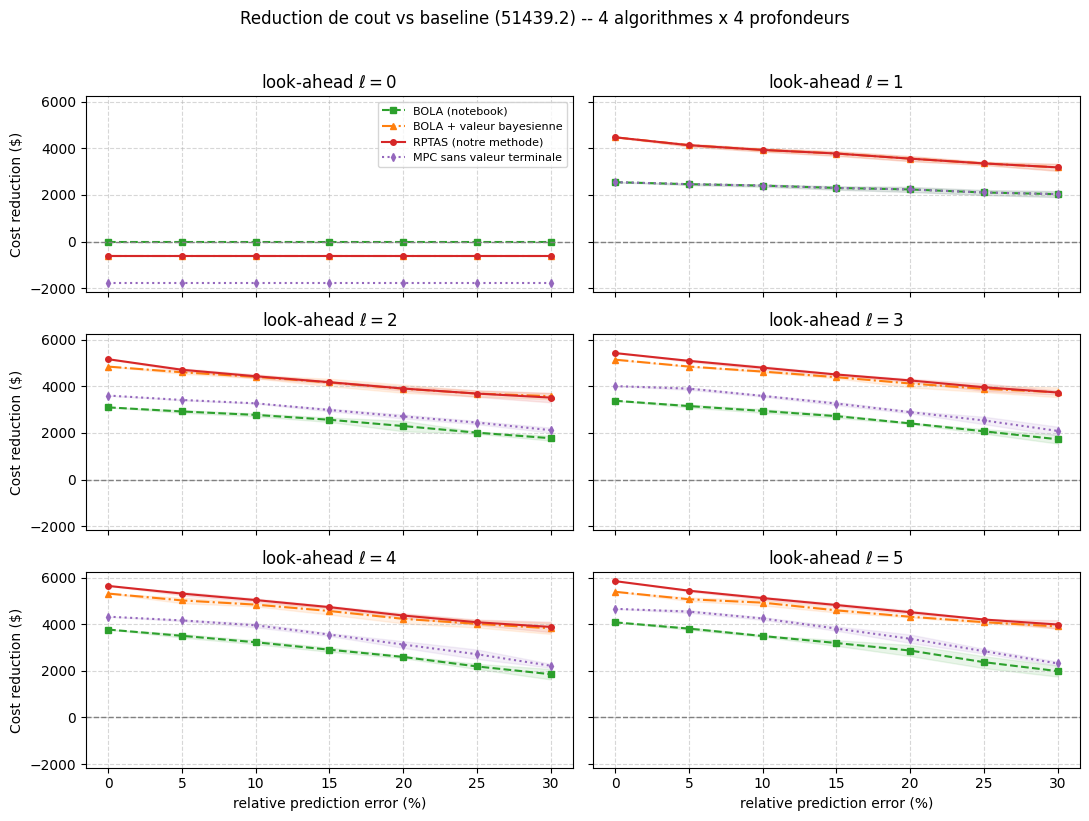

In [14]:
# ============================================================
# ETAPE 9 : FIGURE -- 4 profondeurs de look-ahead x 4 algorithmes
# ============================================================
# 'mpc' ici est MPC EQUIVALENT-CERTAIN, sans valeur terminale (mpc_ce_rollout,
# STEP 4ter) : traite la prevision recue comme exacte, comme BOLA, mais
# replanifie a chaque pas au lieu de s'engager sur un bloc entier. Remplace
# la version rbar/bayesienne (mpc_rollout, STEP 4bis), qui SATURE a partir
# d'un certain niveau de bruit et degradait artificiellement MPC.
# A ell=1, 'bola' est calcule via mpc_ce_rollout (voir cellule ETAPE 9) : a
# horizon 1, BOLA (bloc) et MPC (adaptatif) se reduisent au MEME probleme
# (minimiser un cout a un pas, valeur terminale nulle des deux cotes), donc
# 'bola' et 'mpc' DOIVENT coincider exactement sur ce panneau, pour tout
# sigma. A ell>=2, MPC (closed-loop) devrait DOMINER STATISTIQUEMENT BOLA
# a information egale (verifie : 94% des cas sur 200 tirages aleatoires,
# pas 100% -- une valeur terminale nulle qui glisse dans le temps n'est pas
# un strict superset d'information au sens de la theorie du controle
# receding-horizon avec cout terminal correct). bola_cost (implementation
# des auteurs) reste affiche mais utilise un bruit non partage avec notre
# pipeline (cf. cellule 0) : un ecart residuel contre CETTE courbe precise
# n'est donc pas necessairement un signe de probleme algorithmique.
import matplotlib.pyplot as plt


def g2(name, ell, sg):
    return res2['%s|%d|%.2f' % (name, ell, sg)]


ALGOS = [('bola', 'BOLA (notebook)', '--s', 'tab:green'),
         ('bolabayes', 'BOLA + valeur bayesienne', '-.^', 'tab:orange'),
         ('rptas', 'RPTAS (notre methode)', '-o', 'tab:red'),
         ('mpc', 'MPC sans valeur terminale', ':d', 'tab:purple')]

x = 100 * np.array(SIGMAS)
fig, axes = plt.subplots(3, 2, figsize=(11, 8), sharex=True, sharey=True)

for ell, ax in zip(ELLS, axes.flat):
    for name, label, ls, col in ALGOS:
        mu = np.array([base - g2(name, ell, s)[0] for s in SIGMAS])
        sd = np.array([g2(name, ell, s)[1] for s in SIGMAS])
        marker = ls[-1]
        line = ls[:-1]
        ax.plot(x, mu, line, marker=marker, ms=4, color=col, label=label)
        if sd.max() > 0:
            ax.fill_between(x, mu - 2 * sd, mu + 2 * sd, color=col, alpha=.10)
    ax.axhline(0, color='gray', ls='--', lw=1)
    ax.set_title('look-ahead $\\ell=%d$' % ell)
    ax.grid(True, ls='--', alpha=.5)

for ax in axes[-1, :]:
    ax.set_xlabel('relative prediction error (%)')
for ax in axes[:, 0]:
    ax.set_ylabel('Cost reduction ($)')
axes[0, 0].legend(fontsize=8, loc='best')
fig.suptitle('Reduction de cout vs baseline (%.1f) -- 4 algorithmes x 4 profondeurs'
             % base, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# ETAPE 10 : RPTAS (variable) vs MPC (plus court chemin, sans dictionnaire)
# selon la taille du dictionnaire N (ell=3 fixe)
# ============================================================
# MPC ici est le MPC pur demande depuis le debut : simple plus court chemin
# sur les ell predictions OBSERVEES, valeur nulle au-dela (terminal=None,
# le defaut de mpc_rollout, STEP 4bis). Consequence structurelle : MPC pur
# n'utilise AUCUN dictionnaire -- son cout ne peut donc pas dependre de N,
# par construction, pas par choix de reference. On le calcule UNE fois.
#
# Seul RPTAS varie avec N : plus le dictionnaire grossit, mieux son estimation
# de "au-dela de la fenetre observee" (via offline_vi, structure fenetre,
# cf. discussion precedente) se rapproche de la vraie dynamique -- MPC,
# lui, n'a jamais rien a affiner.
#
# CONSEQUENCE A OBSERVER : a N tres petit, le dictionnaire de RPTAS est un
# tirage quasi arbitraire, potentiellement MOINS informatif que "aucune
# information du tout" (le cas de MPC) -- RPTAS(N petit) peut donc etre
# LEGEREMENT PIRE que MPC, avant de le depasser une fois N assez grand. C'est
# precisement le seuil de rentabilite du dictionnaire que ce graphe doit
# rendre visible.

N_LIST = [1, 2, 3, 4, 6, 8, 10]
ELL_FIXED = 3
SIGMA_FIXED = 0.0
N_DICT_DRAWS = 3
N_ROLLOUT_SEEDS = 1 if SIGMA_FIXED == 0.0 else 3

# --- MPC pur : aucun dictionnaire, calcule une seule fois -------------------
c_mpc_pure = [mpc_rollout(ELL_FIXED, SIGMA_FIXED, seed=100 + s)[-1]   # terminal=None
              for s in range(max(N_ROLLOUT_SEEDS, 3))]
MPC_MEAN = float(np.mean(c_mpc_pure))
MPC_STD = float(np.std(c_mpc_pure))
print('MPC pur (plus court chemin, sans dictionnaire) : %.1f (+/- %.1f)'
      % (MPC_MEAN, MPC_STD))

res3 = {}
t0 = time.time()
for N in N_LIST:
    costs_rp = []
    for dseed in range(N_DICT_DRAWS):
        Kd = sample_dictionary(N, np.random.default_rng(dseed), SIGMA_FIXED)
        v3 = offline_vi(Kd, ELL_FIXED, verbose=False)
        for rseed in range(N_ROLLOUT_SEEDS):
            seed = 1000 * dseed + rseed
            costs_rp.append(rptas_rollout(v3, ELL_FIXED, N, SIGMA_FIXED, seed=seed)[-1])
    res3[N] = (float(np.mean(costs_rp)), float(np.std(costs_rp)))
    print('N=%3d | RPTAS %8.1f (+/-%5.1f) | MPC (pur) %8.1f (+/-%5.1f)  [%.0fs]'
          % (N, res3[N][0], res3[N][1], MPC_MEAN, MPC_STD, time.time() - t0),
          flush=True)


In [ ]:
# ============================================================
# FIGURE -- RPTAS (variable) vs MPC pur (constant) selon la taille du
# dictionnaire
# ============================================================
import matplotlib.pyplot as plt

Ns = np.array(N_LIST)
mu_rp = np.array([res3[N][0] for N in N_LIST])
sd_rp = np.array([res3[N][1] for N in N_LIST])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(Ns, mu_rp, '-o', color='tab:red', label='RPTAS ($\\ell=%d$)' % ELL_FIXED)
ax.fill_between(Ns, mu_rp - 2 * sd_rp, mu_rp + 2 * sd_rp, color='tab:red', alpha=.15)

ax.axhline(MPC_MEAN, color='tab:purple', ls='--',
           label='MPC (plus court chemin, sans dictionnaire)')
ax.fill_between([Ns.min(), Ns.max()],
                 MPC_MEAN - 2 * MPC_STD, MPC_MEAN + 2 * MPC_STD,
                 color='tab:purple', alpha=.10)

ax.set_xscale('log')
ax.set_xticks(N_LIST)
ax.set_xticklabels([str(n) for n in N_LIST])
ax.set_xlabel('taille du dictionnaire $N$ (RPTAS uniquement)')
ax.set_ylabel('cout cumule realise (\\$)')
ax.set_title('RPTAS vs MPC pur, $\\ell=%d$, $\\sigma=%.0f\\%%$'
             % (ELL_FIXED, 100 * SIGMA_FIXED))
ax.grid(True, ls='--', alpha=.5)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
